# Task 2 — Sentiment & Thematic Analysis
## All Banks: CBE · BOA · Dashen

This notebook:
1. Loads the cleaned reviews from Task 1
2. Runs DistilBERT sentiment analysis on every review
3. Extracts top keywords per bank using TF-IDF
4. Assigns each review to a business theme
5. Visualizes results and saves the enriched dataset


## 1. Imports & Setup

In [10]:
import nltk
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hawig\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hawig\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hawig\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\hawig\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\hawig\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


True

In [12]:
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud



# Local modules from src/
from src.sentiment import load_sentiment_pipeline, run_sentiment
from src.themes    import extract_top_keywords, assign_themes, theme_summary

# Paths
CLEAN_PATH  = "../data/raw/reviews_clean.csv"
OUTPUT_PATH = "../data/raw/reviews_analyzed.csv"
PLOTS_DIR   = "../plots"

os.makedirs(PLOTS_DIR, exist_ok=True)
print("Setup complete.")

Setup complete.


## 2. Load Cleaned Data

Load `reviews_clean.csv` produced by Task 1.

In [13]:
df = pd.read_csv(CLEAN_PATH)

print(f"Shape  : {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nReviews per bank:")
print(df["bank"].value_counts().to_string())
df.head()

Shape  : (1209, 5)
Columns: ['review', 'rating', 'date', 'bank', 'source']

Reviews per bank:
bank
Dashen    423
BOA       410
CBE       376


,review,rating,date,bank,source
0,Please make the CBE Noor toggle to be optional...,2,2026-05-17,CBE,Google Play
1,Amazing App,5,2026-05-17,CBE,Google Play
2,It stopped working on its own. When you check ...,1,2026-05-16,CBE,Google Play
3,The most backward and unstable financial app i...,1,2026-05-16,CBE,Google Play
4,ok,5,2026-05-16,CBE,Google Play


## Rating & Data Quality Distribution

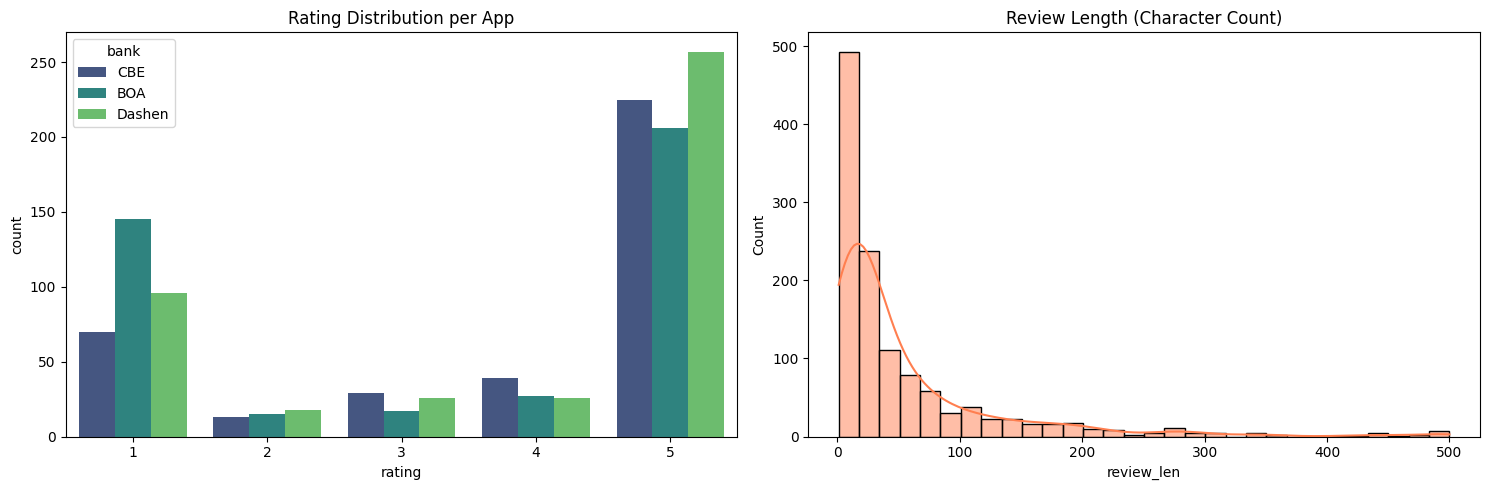

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Rating per App
sns.countplot(data=df, x='rating', hue='bank', palette='viridis', ax=ax[0])
ax[0].set_title('Rating Distribution per App')

# Review Length
df['review_len'] = df['review'].str.len()
sns.histplot(df['review_len'], bins=30, kde=True, ax=ax[1], color='coral')
ax[1].set_title('Review Length (Character Count)')

plt.tight_layout(); plt.show()

## 3. Sentiment Analysis with DistilBERT

### What DistilBERT is
DistilBERT is a smaller, faster version of BERT — a transformer model trained on
millions of sentences to understand natural language context.

Unlike simple rule-based tools, it reads the whole sentence before deciding.
For example:
- `"The app is not bad"` → POSITIVE (understands double negative)
- `"Fast transfers but terrible support"` → depends on which part dominates

### What the score means
- `sentiment_label = 'positive'`, `sentiment_score = 0.98` → very confident it is positive
- `sentiment_label = 'negative'`, `sentiment_score = 0.52` → barely negative — treat with caution

**Note:** The model downloads ~250MB on first run and caches locally after that.

In [14]:
# Load the model (downloads on first run, uses cache after)
pipe = load_sentiment_pipeline()

Loading DistilBERT model (downloads on first run)...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 3836.95it/s]


Model loaded successfully.


In [15]:
# Run sentiment on all reviews
# batch_size=32 is a safe default — reduce to 16 if you run out of memory
df = run_sentiment(df, pipe, batch_size=32)

print(f"\nNew columns added: sentiment_label, sentiment_score")
df[["review", "bank", "sentiment_label", "sentiment_score"]].head(10)

Running sentiment on 1209 reviews (batch_size=32)...

Sentiment distribution (all banks):
  positive  :   638  (52.8%)
  negative  :   571  (47.2%)

New columns added: sentiment_label, sentiment_score


,review,bank,sentiment_label,sentiment_score
0,Please make the CBE Noor toggle to be optional...,CBE,negative,0.9988
1,Amazing App,CBE,positive,0.9999
2,It stopped working on its own. When you check ...,CBE,negative,0.9995
3,The most backward and unstable financial app i...,CBE,negative,0.9997
4,ok,CBE,positive,0.9998
5,Good,CBE,positive,0.9998
6,🤙🏼🤙🏼,CBE,negative,0.6971
7,worst,CBE,negative,0.9998
8,this app very full,CBE,positive,0.9974
9,good apps,CBE,positive,0.9999


### Sentiment breakdown per bank

Check positive vs negative proportions for each bank separately.

In [16]:
sentiment_by_bank = (
    df.groupby(["bank", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
)

# Add percentage columns
for label in ["positive", "negative"]:
    if label in sentiment_by_bank.columns:
        total = sentiment_by_bank.sum(axis=1)
        sentiment_by_bank[f"{label}_pct"] = (sentiment_by_bank[label] / total * 100).round(1)

print(sentiment_by_bank.to_string())

sentiment_label  negative  positive  positive_pct  negative_pct
bank                                                           
BOA                   229       181          44.1          50.4
CBE                   164       212          56.4          37.9
Dashen                178       245          57.9          37.0


## 4. Visualization 1 — Sentiment Distribution (Stacked Bar)

This chart is your opening slide for the client. It immediately shows
which bank has the most dissatisfied users.

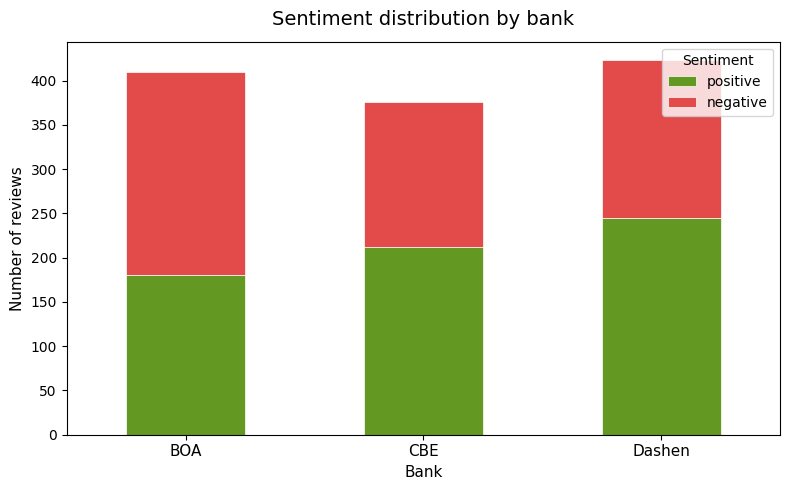

Saved → plots/sentiment_by_bank.png


In [17]:
counts = (
    df.groupby(["bank", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
    [["positive", "negative"]]   # consistent column order
)

fig, ax = plt.subplots(figsize=(8, 5))

counts.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color={"positive": "#639922", "negative": "#E24B4A"},
    edgecolor="white",
    linewidth=0.5,
)

ax.set_title("Sentiment distribution by bank", fontsize=14, pad=12)
ax.set_xlabel("Bank", fontsize=11)
ax.set_ylabel("Number of reviews", fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=11)
ax.legend(title="Sentiment", fontsize=10)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/sentiment_by_bank.png", dpi=150)
plt.show()
print("Saved → plots/sentiment_by_bank.png")

## 5. Visualization 2 — Average Sentiment Score per Bank

The stacked bar shows counts. This chart shows the average confidence
score — a more nuanced view of how strongly users feel.

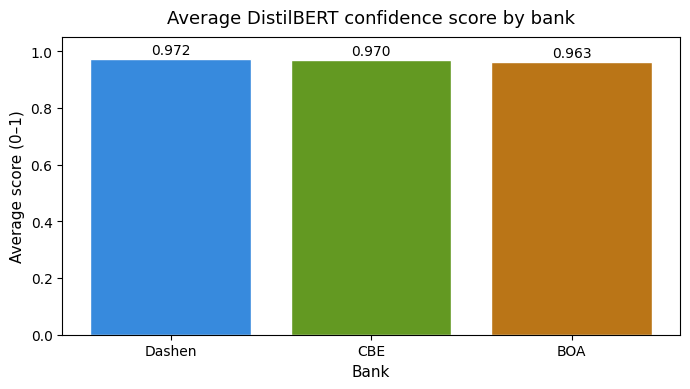

Saved → plots/avg_score_by_bank.png


In [18]:
avg_score = df.groupby("bank")["sentiment_score"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(avg_score.index, avg_score.values,
              color=["#378ADD", "#639922", "#BA7517"], edgecolor="white")

for bar, val in zip(bars, avg_score.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=10)

ax.set_title("Average DistilBERT confidence score by bank", fontsize=13, pad=10)
ax.set_xlabel("Bank", fontsize=11)
ax.set_ylabel("Average score (0–1)", fontsize=11)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/avg_score_by_bank.png", dpi=150)
plt.show()
print("Saved → plots/avg_score_by_bank.png")

## 6. Keyword Extraction with TF-IDF

### What TF-IDF does
- **TF (Term Frequency):** how often a word appears in one review
- **IDF (Inverse Document Frequency):** penalizes words that appear in ALL reviews (like "app", "bank")
- **Result:** words that are distinctively common for ONE bank — these reveal what users talk about most

We use `ngram_range=(1,2)` to capture both single words (`"crash"`)
and two-word phrases (`"login error"`, `"transfer failed"`).

[CBE] Top 10 keywords: ['app', 'good', 'nice', 'work', 'best', 'cbe', 'use', 'update', 'like', 'bank']
[BOA] Top 10 keywords: ['app', 'good', 'work', 'best', 'boa', 'bank', 'bad', 'mobile', 'use', 'banking']
[Dashen] Top 10 keywords: ['app', 'good', 'bank', 'best', 'dashen', 'use', 'nice', 'work', 'easy', 'fast']


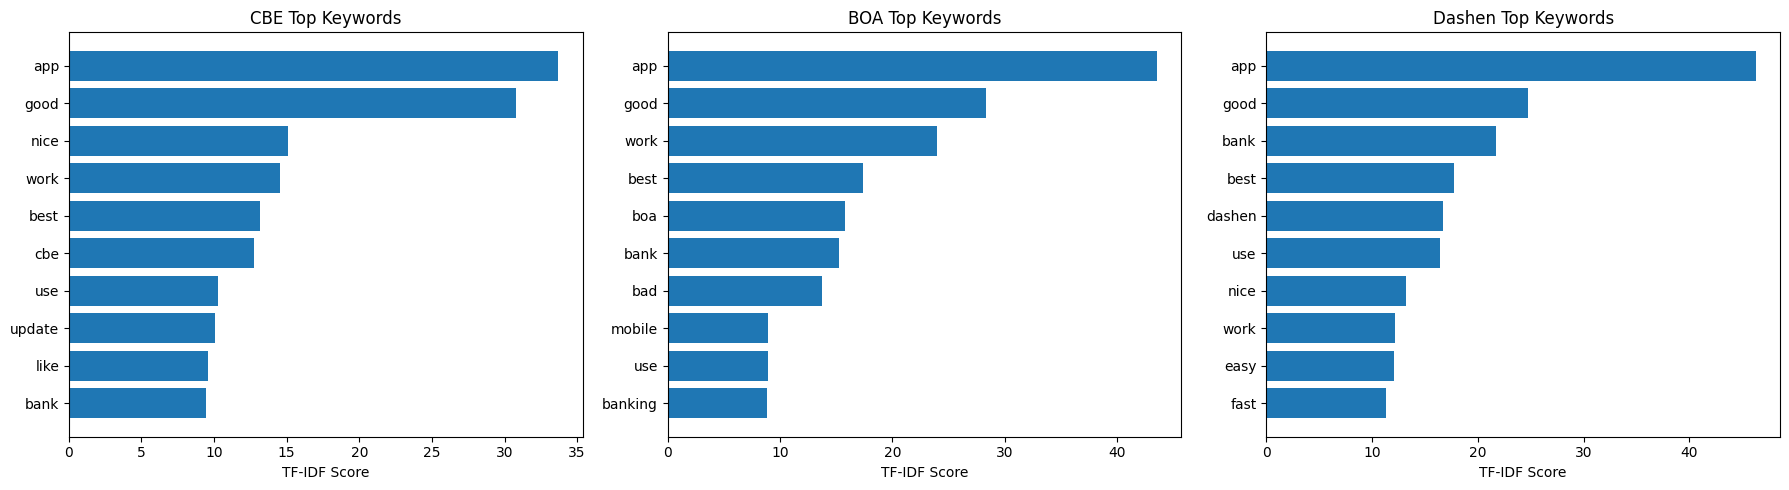

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
banks = ["CBE", "BOA", "Dashen"]
for i, bank in enumerate(banks):
    
    keywords = extract_top_keywords(df, bank_name=bank, top_n=10)
    
    words  = [kw    for kw, score in keywords]   # unpack the tuple
    scores = [score for kw, score in keywords] 

    axes[i].barh(words, scores)

    # Titles and labels
    axes[i].set_title(f"{bank} Top Keywords")
    axes[i].set_xlabel("TF-IDF Score")

    axes[i].invert_yaxis()


# Adjust spacing
plt.tight_layout()


    # Display chart
plt.show()

In [ ]:
text_combined = " ".join(df['reviews'])
wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text_combined)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Review Word Cloud')
plt.show()

KeyError: 'reviews'

## 7. Theme Assignment

After seeing the keywords above, themes are assigned by keyword matching.
The theme map in `src/themes.py` links each business theme to a list of keywords.

**How to update themes:** if you notice a keyword from the TF-IDF output
that is not in the theme map, open `src/themes.py` and add it to the right theme.
Then re-run this cell.

In [ ]:
df = assign_themes(df)

print(f"\nTheme counts per bank:")
print(theme_summary(df).to_string())


Theme distribution (all banks):
identified_theme
General                    809
Transaction Performance    160
App Stability               98
Feature Requests            41
Customer Support            41
Account Access              26
UI & Design                 20
Balance & Account Info      14

Theme counts per bank:
bank                     BOA  CBE  Dashen
identified_theme                         
Account Access            16    2       8
App Stability             41   31      26
Balance & Account Info     4    2       8
Customer Support          13   18      10
Feature Requests          13   10      18
General                  274  259     276
Transaction Performance   45   52      63
UI & Design                4    2      14


## 8. Visualization 3 — Top Themes per Bank

Three side-by-side horizontal bar charts — one per bank.
This is the core deliverable for your client: what are users actually talking about?

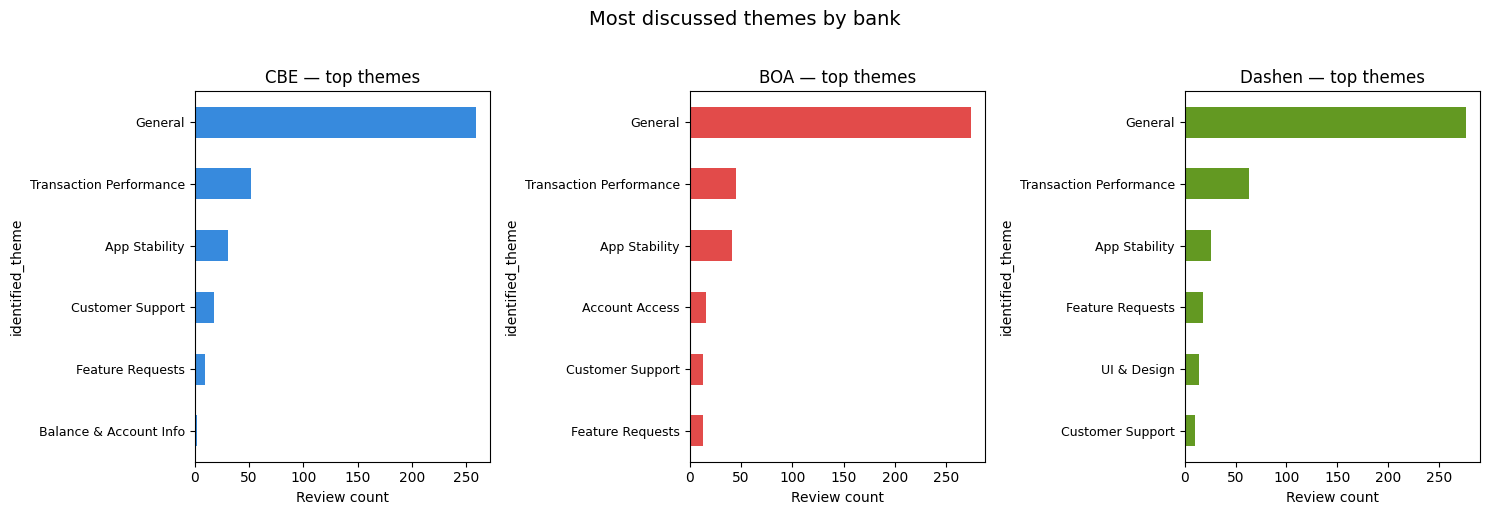

Saved → plots/themes_by_bank.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = {"CBE": "#378ADD", "BOA": "#E24B4A", "Dashen": "#639922"}

for ax, bank in zip(axes, ["CBE", "BOA", "Dashen"]):
    theme_counts = (
        df[df["bank"] == bank]["identified_theme"]
        .value_counts()
        .head(6)
    )
    theme_counts.plot(kind="barh", ax=ax, color=colors[bank])
    ax.set_title(f"{bank} — top themes", fontsize=12)
    ax.set_xlabel("Review count", fontsize=10)
    ax.invert_yaxis()
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle("Most discussed themes by bank", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/themes_by_bank.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → plots/themes_by_bank.png")

## 9. Visualization 4 — Sentiment by Theme (All Banks)

Which themes drive the most negative sentiment?
This tells the client exactly where to focus product investment.

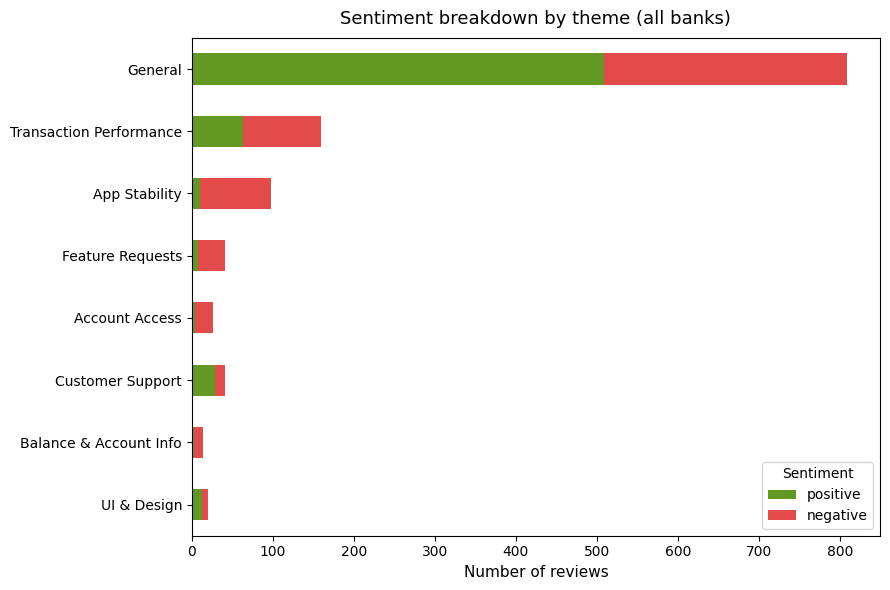

Saved → plots/sentiment_by_theme.png


In [ ]:
theme_sentiment = (
    df.groupby(["identified_theme", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
)

# Sort by negative count descending so the worst themes appear first
if "negative" in theme_sentiment.columns:
    theme_sentiment = theme_sentiment.sort_values("negative", ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
theme_sentiment[["positive", "negative"]].plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color={"positive": "#639922", "negative": "#E24B4A"},
)
ax.set_title("Sentiment breakdown by theme (all banks)", fontsize=13, pad=10)
ax.set_xlabel("Number of reviews", fontsize=11)
ax.set_ylabel("")
ax.legend(title="Sentiment", fontsize=10)

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/sentiment_by_theme.png", dpi=150)
plt.show()
print("Saved → plots/sentiment_by_theme.png")

## 10. Save Analyzed Dataset

Save the enriched DataFrame with all new columns for use in Task 3 (PostgreSQL).

In [ ]:
final_cols = [
    "review", "rating", "date", "bank", "source",
    "sentiment_label", "sentiment_score", "identified_theme"
]

df[final_cols].to_csv(OUTPUT_PATH, index=False)

print(f"Analyzed dataset saved → {OUTPUT_PATH}")
print(f"Columns : {final_cols}")
print(f"Shape   : {df[final_cols].shape}")

Analyzed dataset saved → ../data/raw/reviews_analyzed.csv
Columns : ['review', 'rating', 'date', 'bank', 'source', 'sentiment_label', 'sentiment_score', 'identified_theme']
Shape   : (1209, 8)


## 11. Task 2 Summary

Document your key findings here. Replace the examples with your real numbers
after running the notebook.

---

### Sentiment findings
| Bank | Positive | Negative | Avg Score |
|------|----------|----------|-----------|
| CBE  | 57.1%%   | __%      | 0.97       |
| BOA  | 44.1%    | __%      | o.93       |
| Dashen | 57.9%  | __%      | 0.97       |



